In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit

In [3]:
df = pd.read_csv("solar_system.csv", index_col=0)
df

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
Attribute,,,,,,,,,,
Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8


In [4]:
print (df.shape)
print (df.shape[0])
print (df.shape[1])

print (df.head())
print (df.tail())
print (df.columns)
print (df.index)

(20, 10)
20
10
                       Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
Attribute                                                                    
Mass (10^24kg)           0.330   4.87   5.97  0.073  0.642    1898     568   
Diameter (km)             4879  12104  12756   3475   6792  142984  120536   
Density (kg/m^3)          5429   5243   5514   3340   3934    1326     687   
Gravity (m/s^2)            3.7    8.9    9.8    1.6    3.7    23.1     9.0   
Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

                       Uranus Neptune   Pluto  
Attribute                                      
Mass (10^24kg)           86.8     102  0.0130  
Diameter (km)           51118   49528    2376  
Density (kg/m^3)         1270    1638    1850  
Gravity (m/s^2)           8.7    11.0     0.7  
Escape Velocity (km/s)   21.3    23.5     1.3  
                        Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
Attribute                 

In [6]:
orbital_period = df.iloc[10].astype(float)
perihelion = df.iloc[9].astype(float)
aphelion = df.iloc[8].astype(float)

print (orbital_period)
print (perihelion)
print (aphelion)

Mercury       88.0
Venus        224.7
Earth        365.2
Moon          27.3
Mars         687.0
Jupiter     4331.0
Saturn     10747.0
Uranus     30589.0
Neptune    59800.0
Pluto      90560.0
Name: Orbital Period (days), dtype: float64
Mercury      69.800
Venus       108.900
Earth       152.100
Moon          0.406
Mars        249.300
Jupiter     816.400
Saturn     1506.500
Uranus     3001.400
Neptune    4558.900
Pluto      7375.900
Name: Aphelion (10^6 km), dtype: float64
Mercury      46.000
Venus       107.500
Earth       147.100
Moon          0.363
Mars        206.700
Jupiter     740.600
Saturn     1357.600
Uranus     2732.700
Neptune    4471.100
Pluto      4436.800
Name: Perihelion (10^6 km), dtype: float64


In [7]:
# perihelion is the point in an orbit where an object is closest to the sun 
# aphelion is the point in an orbit where an object is farthest from the sun 
# orbit period is the amount of time it takes to make one orbit around the sun in days.


In [8]:
semi_major_axis = (perihelion + aphelion) / 2 

print ("Semi_major Axis:")
print (semi_major_axis)

Semi_major Axis:
Mercury      57.9000
Venus       108.2000
Earth       149.6000
Moon          0.3845
Mars        228.0000
Jupiter     778.5000
Saturn     1432.0500
Uranus     2867.0500
Neptune    4515.0000
Pluto      5906.3500
dtype: float64


In [10]:
semi_major_axis_row = pd.Series(semi_major_axis, name ="Semi-major axis (AU)")
df = pd.concat([df, semi_major_axis_row.to_frame().T])

df

,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
Mass (10^24kg),0.330,4.87,5.97,0.073,0.642,1898,568,86.8,102,0.0130
Diameter (km),4879,12104,12756,3475,6792,142984,120536,51118,49528,2376
Density (kg/m^3),5429,5243,5514,3340,3934,1326,687,1270,1638,1850
Gravity (m/s^2),3.7,8.9,9.8,1.6,3.7,23.1,9.0,8.7,11.0,0.7
Escape Velocity (km/s),4.3,10.4,11.2,2.4,5.0,59.5,35.5,21.3,23.5,1.3
Rotation Period (hours),1407.6,-5832.5,23.9,655.7,24.6,9.9,10.7,-17.2,16.1,-153.3
Length of Day (hours),4222.6,2802.0,24.0,708.7,24.7,9.9,10.7,17.2,16.1,153.3
Distance from Sun (10^6 km),57.9,108.2,149.6,0.384,228.0,778.5,1432.0,2867.0,4515.0,5906.4
Perihelion (10^6 km),46.0,107.5,147.1,0.363,206.7,740.6,1357.6,2732.7,4471.1,4436.8
Aphelion (10^6 km),69.8,108.9,152.1,0.406,249.3,816.4,1506.5,3001.4,4558.9,7375.9


In [11]:
print (df.shape)
print(df.shape[0])
print (df.shape[1])


(21, 10)
21
10


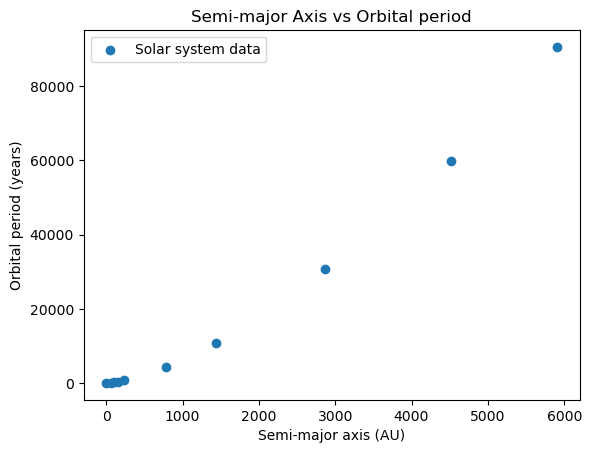

In [12]:
plt.scatter(semi_major_axis, orbital_period, label="Solar system data")
plt.xlabel("Semi-major axis (AU)")
plt.ylabel("Orbital period (years)")
plt.title("Semi-major Axis vs Orbital period") 
plt.legend()
plt.show()

In [13]:
def keplers_third_law(a,m):
    return m * a**1.5


In [14]:
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period)
m_fit = popt[0]

print (f"Fit: T = {m_fit:.2f} * a^1.5")

Fit: T = 0.20 * a^1.5


In [15]:
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(semi_major_axis) - len(popt)
chi2_reduced = chi2 / dof

print (f"Reduced chi-squared: {chi2_reduced: .2f}")

Reduced chi-squared:  41276.71


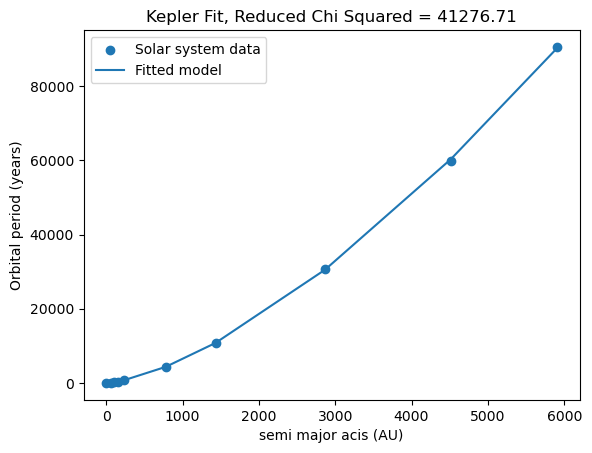

In [16]:
a_sorted = np.sort(semi_major_axis) 
T_fit_sorted = keplers_third_law(a_sorted, m_fit) 

plt.scatter(semi_major_axis, orbital_period, label = "Solar system data")
plt.plot (a_sorted, T_fit_sorted, label="Fitted model")
plt.xlabel ("semi major acis (AU)") 
plt.ylabel("Orbital period (years)")
plt.title(f"Kepler Fit, Reduced Chi Squared = {chi2_reduced:.2f}")
plt.legend()
plt.show()

In [17]:
df.to_csv("kepler.csv")